# 2.0 Machine Learning For Regression

In [179]:
import numpy as np
import pandas as pd

# 2.1 Data Preperation

In [180]:
data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv"

In [181]:
df = pd.read_csv("../dataset-week2/data.csv")


In [182]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [183]:
df.columns = df.columns.str.lower().str.replace(" ", "_")    # data cleaning

In [184]:
df.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


In [185]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [186]:
# here we are seperating the str datatypes
df.dtypes[df.dtypes == "str"]

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [187]:
# here we are geting the index of the str in the table and converting them to the list and storing it into a variable
strings = list(df.dtypes[df.dtypes == "str"].index)   
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [188]:
# here we are using loop to apply the cleaning to all the elements  of the strings to get cleaner dataframe
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ","_")

In [189]:
df.head(3)  # here now the dataframe looks much cleaner

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350


# 2.2 Exploratory Data Analysis

In [190]:
for col in df.columns:
    print(col)                           # printing col name
    print(df[col].unique()[:5])          # printing 5 unique values from the column
    print(df[col].nunique())             # printing how many total unique values are there in the column
    print()                              # used for spacing


make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

## Distribution of price

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

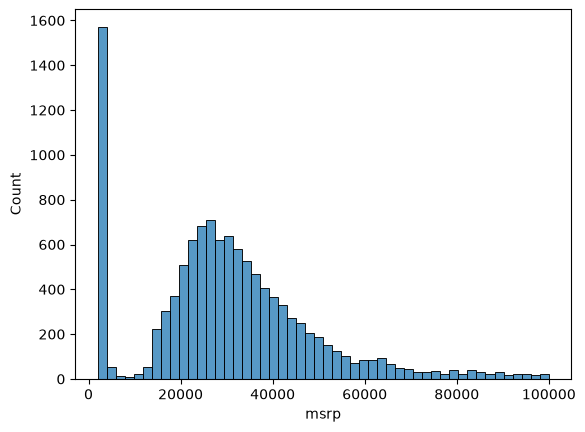

In [192]:
sns.histplot(df.msrp[df.msrp < 100000] , bins = 50)     # here bins= 50 means (how many bars we have)  # 1e^6 = 10^6 (1 million)

In [193]:
# now we cannot keep this graph as it can confuse the model aso we will use logarithmic values  (rn the graph is "Long Tail Distribution")
# and we also add 1 to the every values so we dont get the -ve log values so we use (np.log1p() function)
price_logs = np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

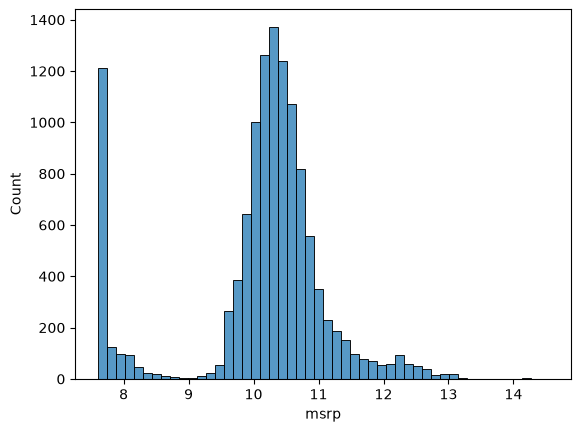

In [194]:
sns.histplot(price_logs , bins = 50)   # now the graph looks like noramal distribution so now its ideal for model training   (rn the graph is "Normal Distribution")

## Missing Values

In [195]:
df.isnull().sum()  # here we are looking for how many null values we have 

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 Setting Up the validation framework

In [196]:
# here we spltit the dataframe in three parts 1)Train 2)validation 3)Test
n = len(df)   

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
 # here we do this so we dont loose any values in the data set , as due to rounding we have lost some values (we clud also have used the (n_train = int(n * 0.6) but it losses some values))   

In [197]:
n_train , n_val ,n_test   # now we know the size of the dataset

(7150, 2382, 2382)

In [198]:
# Spliting the DataFrame into train, validation, and test sets using row indices
df_train = df.iloc[ : n_train]
df_val = df.iloc[ n_train : n_train + n_val]
df_test = df.iloc[ n_train + n_val : ]


In [199]:
idx = np.arange(n)    # Create a list of all row numbers before shuffling

In [200]:
# here we are suffeling the data to break any accidental order opr recurring values ,as shuffeling helps model train well
np.random.seed(2)
np.random.shuffle(idx)

In [201]:
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [202]:
# now we are writing the shuffeled data by adding idx to the  split dataset
df_train = df.iloc[idx[  : n_train ]]
df_val = df.iloc[idx[ n_train : n_train + n_val]]
df_test = df.iloc[idx[ n_train + n_val : ]]



In [203]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [204]:
# Reset row indices to start from 0 and remove the old shuffled indices
df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [205]:
# Convert the target variable (MSRP) into log scale for better model performance
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [206]:
# Remove the target column (MSRP) from the feature DataFrames (so we dont accidently use it for training purpose)
del df_train["msrp"]
del df_val["msrp"]
del df_test["msrp"]